## Jet Image Pre-training with Vision Transformer

This notebook sets up a self-supervised pre-training pipeline for jet images using an unlabelled HDF5 dataset.

1. **Data Inspection** – Open the HDF5 file and examine the structure/shape of the `jet` dataset (125×125×8 images with 8 channels).
2. **PyTorch Dataset** – Define `JetUnlabelledDataset`, which lazily loads jet images, converts them to `(C, H, W)` tensors, and applies zero-mean/unit-variance normalization.
3. **Train / Val Split & DataLoaders** – Split the dataset 95/5 into training and validation sets and wrap them in `DataLoader`s for batched iteration.

In [46]:
import h5py
import torch
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import random_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import random

import numpy as np
import torch.nn as nn
import torch.nn.functional as F

In [34]:
with h5py.File('data/Dataset_Specific_Unlabelled.h5', 'r') as f:
    print("Top-level keys:", list(f.keys()))

    jet = f['jet']
    print("Type of 'jet':", type(jet))

    if isinstance(jet, h5py.Dataset):
        print("Shape:", jet.shape)
        first = jet[0]
        print("First item shape:", first.shape)

Top-level keys: ['jet']
Type of 'jet': <class 'h5py._hl.dataset.Dataset'>
Shape: (60000, 125, 125, 8)
First item shape: (125, 125, 8)


In [35]:
class JetUnlabelledDataset(Dataset):
    def __init__(self, h5_path):
        self.h5_path = h5_path
        self.file = None  # opened lazily

        # read shape without keeping file open
        with h5py.File(h5_path, "r") as f:
            self.length = f["jet"].shape[0]

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        # open file inside worker if needed
        if self.file is None:
            self.file = h5py.File(self.h5_path, "r")
        
        x = self.file["jet"][idx]  # (125,125,8)
        x = torch.tensor(x, dtype=torch.float32)

        # convert to (C,H,W)
        x = x.permute(2, 0, 1)

        x = (x - x.mean()) / (x.std() + 1e-6)

        return x

In [36]:
dataset = JetUnlabelledDataset("data/Dataset_Specific_Unlabelled.h5")

val_size = int(0.05 * len(dataset))
train_size = len(dataset) - val_size

train_ds, val_ds = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)

## Sanity Check: Visualizing Ulabelled and Labelled Data

Before training any model, I must verify what the input data looks like.

Sample shape: torch.Size([8, 125, 125])
Min value: -0.08588849753141403
Max value: 28.39854621887207
Mean value: -3.906249990137667e-09
Std value: 0.9999999403953552


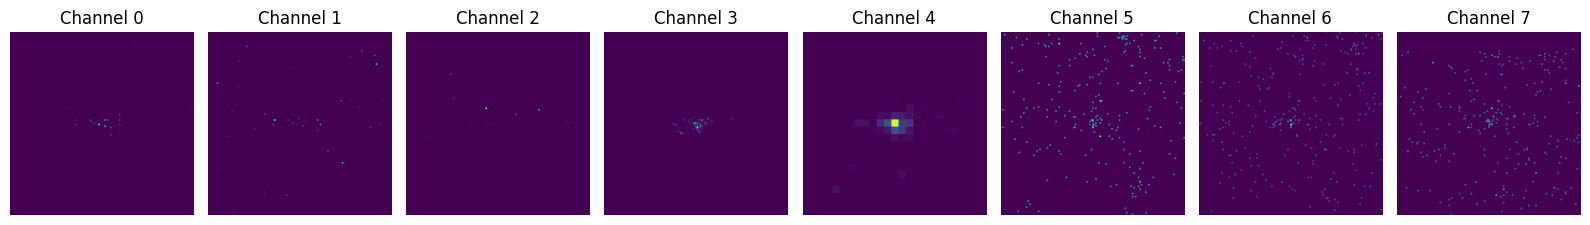

In [37]:
# get one random sample from training dataset
idx = random.randint(0, len(train_ds)-1)
sample = train_ds[idx]   # shape: (8,125,125)

print("Sample shape:", sample.shape)
print("Min value:", sample.min().item())
print("Max value:", sample.max().item())
print("Mean value:", sample.mean().item())
print("Std value:", sample.std().item())

# visualize first 4 channels
num_channels_to_plot = 8

fig, axes = plt.subplots(1, num_channels_to_plot, figsize=(16,4))

for i in range(num_channels_to_plot):
    axes[i].imshow(sample[i].cpu(), cmap="viridis")
    axes[i].set_title(f"Channel {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [38]:
path = "data/Dataset_Specific_labelled_full_only_for_2i.h5"

def explore(name, obj):
    if isinstance(obj, h5py.Dataset):
        print(f"{name} -> DATASET shape={obj.shape} dtype={obj.dtype}")
    else:
        print(f"{name} -> GROUP")

with h5py.File(path, "r") as f:
    print("Top-level keys:", list(f.keys()))
    print("\nFull structure:\n")
    f.visititems(explore)

with h5py.File(path, "r") as f:
    jet = f["jet"][0]
    print("Jet shape:", jet.shape)

    for k in f.keys():
        if k != "jet":
            print(k, "sample value:", f[k][0])

Top-level keys: ['Y', 'jet', 'm', 'pT']

Full structure:

Y -> DATASET shape=(10000, 1) dtype=float32
jet -> DATASET shape=(10000, 125, 125, 8) dtype=float32
m -> DATASET shape=(10000, 1) dtype=float32
pT -> DATASET shape=(10000, 1) dtype=float32
Jet shape: (125, 125, 8)
Y sample value: [1.]
m sample value: [136.34013]
pT sample value: [551.3493]


---------[Y]---------
Shape: (10000,)
dtype: float32
Min: 0.0
Max: 1.0
Unique values (first 20): [0. 1.]
Number of unique values: 2
---------[m]---------
Shape: (10000,)
dtype: float32
Min: 31.948496
Max: 728.3518
Unique values (first 20): [31.948496 37.162827 37.652603 38.178566 40.40662  42.476177 43.35503
 43.417694 44.285244 45.752937 46.323708 46.597603 46.610394 46.872013
 46.905388 46.91361  46.92877  46.98776  46.99083  47.015266]
Number of unique values: 9993
---------[pT]---------
Shape: (10000,)
dtype: float32
Min: 400.01608
Max: 2039.6335
Unique values (first 20): [400.01608 400.04034 400.05087 400.07315 400.0838  400.0869  400.2837
 400.2934  400.31705 400.34348 400.4446  400.46985 400.47272 400.48547
 400.48703 400.49677 400.51898 400.5383  400.53998 400.5431 ]
Number of unique values: 9984


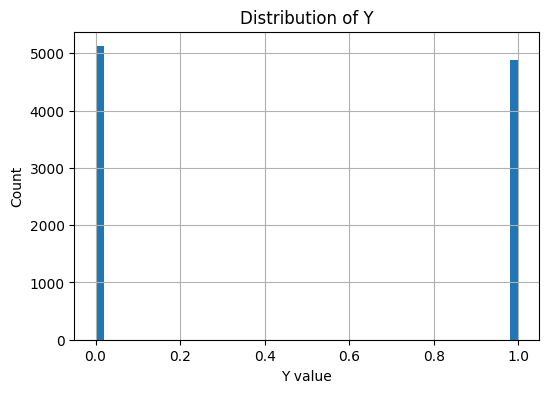

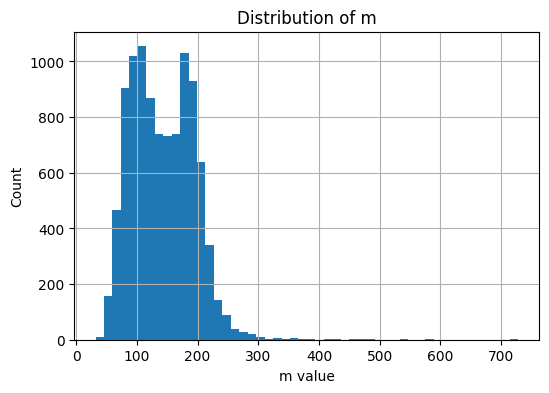

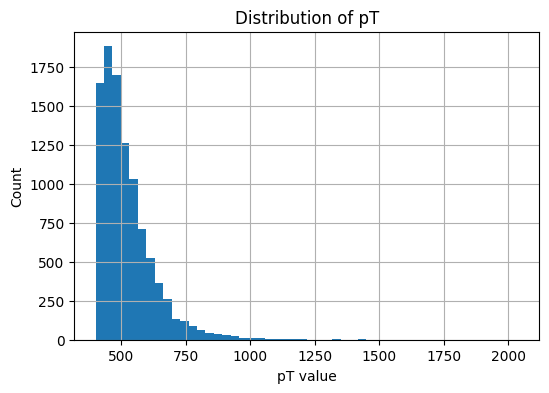

In [39]:
with h5py.File(path, "r") as f:
    Y = f["Y"][:].squeeze()
    m = f["m"][:].squeeze()
    pT = f["pT"][:].squeeze()

print("---------[Y]---------")
print("Shape:", Y.shape)
print("dtype:", Y.dtype)
print("Min:", Y.min())
print("Max:", Y.max())
print("Unique values (first 20):", np.unique(Y)[:20])
print("Number of unique values:", len(np.unique(Y)))

print("---------[m]---------")
print("Shape:", m.shape)
print("dtype:", m.dtype)
print("Min:", m.min())
print("Max:", m.max())
print("Unique values (first 20):", np.unique(m)[:20])
print("Number of unique values:", len(np.unique(m)))

print("---------[pT]---------")
print("Shape:", pT.shape)
print("dtype:", pT.dtype)
print("Min:", pT.min())
print("Max:", pT.max())
print("Unique values (first 20):", np.unique(pT)[:20])
print("Number of unique values:", len(np.unique(pT)))

# histogram
plt.figure(figsize=(6,4))
plt.hist(Y, bins=50)
plt.title("Distribution of Y")
plt.xlabel("Y value")
plt.ylabel("Count")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.hist(m, bins=50)
plt.title("Distribution of m")
plt.xlabel("m value")
plt.ylabel("Count")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.hist(pT, bins=50)
plt.title("Distribution of pT")
plt.xlabel("pT value")
plt.ylabel("Count")
plt.grid(True)
plt.show()

## Pretraining: Masked Autoencoder for Jet Representation Learning

I pretrain a Vision Transformer encoder on the unlabelled jet dataset using a masked reconstruction objective.

Each jet image (8 × 125 × 125) is split into 5×5 patches → 625 tokens.

During training:
- 75% of patches are randomly masked
- Encoder processes only visible patches
- A lightweight decoder reconstructs the original patches
- Loss = Mean Squared Error between Masked Patches

After pretraining, I will:
- Save encoder weights
- Fine-tune on labelled dataset
- Compare against training from scratch

In [44]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

class PatchEmbed(nn.Module):
    def __init__(self, in_ch=8, embed_dim=256, patch=5):
        super().__init__()
        self.patch = patch
        self.proj = nn.Conv2d(in_ch, embed_dim,
                              kernel_size=patch,
                              stride=patch)

    def forward(self, x):
        x = self.proj(x)                        # (B, D, 25, 25)
        B, D, H, W = x.shape
        x = x.permute(0, 2, 3, 1).contiguous()  # (B, 25, 25, D)
        x = x.reshape(B, H * W, D)              # (B, 625, D)
        return x

class Attention(nn.Module):
    def __init__(self, dim, heads=8, eps=1e-6):
        super().__init__()
        if dim % heads != 0:
            raise ValueError("dim must be divisible by heads")

        self.norm = nn.LayerNorm(dim)
        self.heads = heads
        self.head_dim = dim // heads
        self.eps = eps

        self.to_qkv = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x):
        y = self.norm(x)
        B, N, C = y.shape

        qkv = self.to_qkv(y).reshape(B, N, 3, self.heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B, H, N, Dh)
        q, k, v = qkv[0], qkv[1], qkv[2]

        q = F.elu(q) + 1.0
        k = F.elu(k) + 1.0

        kv = torch.einsum("b h n d, b h n e -> b h d e", k, v)
        k_sum = k.sum(dim=2)  # (B, H, Dh)

        z = 1.0 / (torch.einsum("b h n d, b h d -> b h n", q, k_sum) + self.eps)
        out = torch.einsum("b h n d, b h d e, b h n -> b h n e", q, kv, z)

        out = out.transpose(1, 2).contiguous().reshape(B, N, C)
        out = self.proj(out)
        return out

class Block(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = Attention(dim)
        self.ff = nn.Sequential(
            nn.Linear(dim, dim*4),
            nn.GELU(),
            nn.Linear(dim*4, dim)
        )
        self.n2 = nn.LayerNorm(dim)

    def forward(self,x):
        x = x + self.attn(x)
        x = x + self.ff(self.n2(x))
        return x

class Encoder(nn.Module):
    def __init__(self, dim=256, depth=4):
        super().__init__()
        self.patch = PatchEmbed()
        self.pos = nn.Parameter(torch.randn(1, 625, dim))
        self.blocks = nn.Sequential(*[Block(dim) for _ in range(depth)])
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        x = self.patch(x)
        x = x + self.pos
        x = self.blocks(x)
        x = self.norm(x)
        return x

class MAE(nn.Module):
    def __init__(self, dim=256, mask_ratio=0.60):
        super().__init__()
        self.encoder = Encoder(dim)
        # Simple projection head to get back to pixels
        self.decoder = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Linear(dim, 8*5*5) # 8 channels * 5x5 patch
        )
        self.mask_ratio = mask_ratio
        self.patch_size = 5
        
        # 1. Learnable [MASK] token
        self.mask_token = nn.Parameter(torch.zeros(1, 1, dim))
        torch.nn.init.normal_(self.mask_token, std=.02)

    def patchify(self, imgs):
        B, C, H, W = imgs.shape
        p = self.patch_size
        h, w = H // p, W // p
        x = imgs.reshape(B, C, h, p, w, p)
        x = x.permute(0, 2, 4, 1, 3, 5).contiguous()
        x = x.reshape(B, h * w, C * p * p)
        return x

    def forward(self, x):
        B = x.size(0)
        
        # 1. Create Ground Truth Patches
        target = self.patchify(x)
        
        # 2. Create Embeddings
        tokens = self.encoder.patch(x) # (B, N, D)
        B, N, D = tokens.shape

        # 3. Create Mask
        mask_count = int(N * self.mask_ratio)
        noise = torch.rand(B, N, device=x.device)
        ids = torch.argsort(noise, dim=1)
        
        # indices to mask (the first 'mask_count' ones)
        mask_idx = ids[:, :mask_count]
        
        # 4. Apply Masking
        # cloning tokens so I don't overwrite the original tensor in place incorrectly
        masked_tokens = tokens.clone()
        
        # Advanced indexing to replace masked positions with the learnable parameter
        batch_range = torch.arange(B, device=x.device)[:, None]
        masked_tokens[batch_range, mask_idx] = self.mask_token

        # 5. Add Positional Embeddings & Encode
        masked_tokens = masked_tokens + self.encoder.pos
        encoded = self.encoder.blocks(masked_tokens)
        encoded = self.encoder.norm(encoded)

        # 6. Predict Everything
        reconstruction = self.decoder(encoded) # (B, N, 8*5*5)

        # 7. Calculate Loss ONLY on Masked Patches
        # Gather the predictions at the masked indices
        pred_masked = reconstruction[batch_range, mask_idx]
        
        # Gather the ground truth at the masked indices
        target_masked = target[batch_range, mask_idx]
        
        loss = ((pred_masked - target_masked)**2).mean()
        
        return loss

Using device: cuda


Epoch 1/20:   0%|          | 0/1782 [00:00<?, ?it/s]

Epoch 1/20: 100%|██████████| 1782/1782 [02:55<00:00, 10.13it/s, loss=0.778]


Epoch 1: Train_loss=0.8246 | Val_loss=0.8101


Epoch 2/20: 100%|██████████| 1782/1782 [02:52<00:00, 10.34it/s, loss=0.808]


...

Epoch 18: Train_loss=0.7885 | Val_loss=0.7932


Epoch 19/20: 100%|██████████| 1782/1782 [08:02<00:00,  3.70it/s, loss=0.796]


Epoch 19: Train_loss=0.7880 | Val_loss=0.7914


Epoch 20/20: 100%|██████████| 1782/1782 [08:43<00:00,  3.40it/s, loss=0.722]


Epoch 20: Train_loss=0.7873 | Val_loss=0.7902


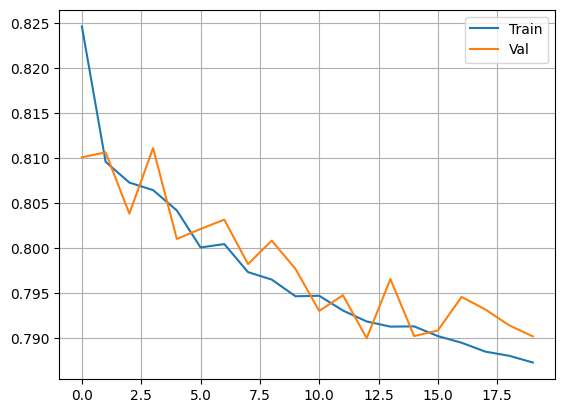

In [45]:
print("Using device:", device)

model = MAE().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 20
train_history = []
val_history = []

for epoch in range(epochs):
    model.train()
    train_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for batch in loop:
        if isinstance(batch, (list, tuple)):
            batch = batch[0]
        batch = batch.to(device)

        loss = model(batch)

        opt.zero_grad()
        loss.backward()
        opt.step()

        train_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    train_loss /= len(train_loader)
    train_history.append(train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            if isinstance(batch, (list, tuple)):
                batch = batch[0]
            batch = batch.to(device)
            loss = model(batch)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_history.append(val_loss)

    print(f"Epoch {epoch+1}: Train_loss={train_loss:.4f} | Val_loss={val_loss:.4f}")

torch.save(model.encoder.state_dict(), "pretrained_encoder_60_percent_masking.pt")

plt.plot(train_history, label="Train")
plt.plot(val_history, label="Val")
plt.legend()
plt.grid(True)
plt.show()

## Fine-tuning for Binary Classification

The labelled dataset contains:

- jet: (10000, 125, 125, 8)
- Y:   binary labels {0,1}

We therefore treat this as a binary classification task.

Procedure:
1. 80% train / 20% test split
2. Fine-tune pretrained encoder with low learning rate
3. Train identical model from scratch
4. Compare test accuracy and training dynamics

Loss: Binary Cross Entropy with Logits
Metric: Accuracy

In [17]:
import h5py
import torch
from torch.utils.data import Dataset, DataLoader, random_split

class JetDataset(Dataset):
    def __init__(self, h5_path, task="cls"):
        self.h5_path = h5_path
        self.file = None
        self.task = task

        with h5py.File(h5_path, "r") as f:
            self.length = f["jet"].shape[0]
            self.available_keys = set(f.keys())

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        if self.file is None:
            self.file = h5py.File(self.h5_path, "r")

        x = self.file["jet"][idx]
        x = torch.tensor(x, dtype=torch.float32).permute(2, 0, 1)
        x = (x - x.mean()) / (x.std() + 1e-6)

        if self.task == "cls":
            y = self.file["Y"][idx]
        elif self.task == "mass":
            if "m" not in self.available_keys:
                raise KeyError("Dataset missing key 'm' for mass regression")
            y = self.file["m"][idx]
        elif self.task == "pt":
            if "pT" not in self.available_keys:
                raise KeyError("Dataset missing key 'pT' for pT regression")
            y = self.file["pT"][idx]
        else:
            raise ValueError(f"Unknown task: {self.task}")

        y = torch.tensor(y, dtype=torch.float32).squeeze()
        return x, y

In [18]:
def make_loaders(task, batch_size=32, val_frac_from_train=0.1):
    dataset = JetDataset("data/Dataset_Specific_labelled_full_only_for_2i.h5", task)

    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size

    train_full, test_ds = random_split(
        dataset,
        [train_size, test_size],
        generator=torch.Generator().manual_seed(42)
    )

    val_size = int(val_frac_from_train * len(train_full))
    val_size = max(1, val_size)
    train_size_final = len(train_full) - val_size

    train_ds, val_ds = random_split(
        train_full,
        [train_size_final, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

In [19]:
import torch.nn as nn

class FinetuneModel(nn.Module):
    def __init__(self, encoder, out_dim=1):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Linear(256, out_dim)

    def forward(self, x):
        z = self.encoder(x).mean(dim=1)
        return self.head(z)

In [50]:
import numpy as np
import copy
import os

torch.manual_seed(67)
np.random.seed(67)

os.makedirs("weights", exist_ok=True)

def build_model(pretrained=True):
    encoder = Encoder().to(device)
    if pretrained:
        state = torch.load("pretrained_encoder_60_percent_masking.pt", map_location=device)
        encoder.load_state_dict(state)
    return FinetuneModel(encoder).to(device)

In [48]:
from tqdm import tqdm
import matplotlib.pyplot as plt

def evaluate_regression(model, loader):
    model.eval()
    total_loss = 0.0
    criterion = nn.MSELoss()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device).float().view(-1)
            pred = model(x).squeeze(-1)
            loss = criterion(pred, y)
            total_loss += loss.item()
    return total_loss / max(1, len(loader))

def evaluate_classification(model, loader):
    model.eval()
    criterion = nn.BCEWithLogitsLoss()
    total_loss = 0.0
    logits_all, labels_all = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device).float().view(-1)
            logits = model(x).squeeze(-1)
            loss = criterion(logits, y)

            total_loss += loss.item()
            logits_all.append(logits.detach().cpu())
            labels_all.append(y.detach().cpu())

    logits_all = torch.cat(logits_all).numpy()
    labels_all = torch.cat(labels_all).numpy()
    probs = 1.0 / (1.0 + np.exp(-logits_all))
    preds = (probs >= 0.5).astype(np.int32)
    acc = (preds == labels_all.astype(np.int32)).mean()

    return {
        "loss": total_loss / max(1, len(loader)),
        "labels": labels_all.astype(np.int32),
        "probs": probs,
        "preds": preds,
        "acc": acc,
    }

def train_and_eval(task, pretrained=True, lr=1e-4, epochs=12, patience=3):
    train_loader, val_loader, test_loader = make_loaders(task)
    model = build_model(pretrained=pretrained)

    is_cls = task == "cls"
    criterion = nn.BCEWithLogitsLoss() if is_cls else nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    history = {"train": [], "val": [], "train_acc": [], "val_acc": []}
    best_state = None
    best_val = float("inf")
    bad_epochs = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for x, y in tqdm(train_loader, leave=False, desc=f"{task} ep {epoch+1}/{epochs}"):
            x = x.to(device)
            y = y.to(device).float().view(-1)

            out = model(x).squeeze(-1)
            loss = criterion(out, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            if is_cls:
                probs = torch.sigmoid(out)
                preds = (probs >= 0.5).float()
                train_correct += (preds == y).sum().item()
                train_total += y.numel()

        train_loss /= max(1, len(train_loader))

        if is_cls:
            val_metrics = evaluate_classification(model, val_loader)
            val_loss = val_metrics["loss"]
            train_acc = train_correct / max(1, train_total)
            val_acc = val_metrics["acc"]
        else:
            val_loss = evaluate_regression(model, val_loader)
            train_acc = np.nan
            val_acc = np.nan

        history["train"].append(train_loss)
        history["val"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        improved = val_loss < best_val
        if improved:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if is_cls:
            print(f"{task} | {'pre' if pretrained else 'scratch'} | epoch {epoch+1} | train={train_loss:.4f} | val={val_loss:.4f} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f}")
        else:
            print(f"{task} | {'pre' if pretrained else 'scratch'} | epoch {epoch+1} | train={train_loss:.4f} | val={val_loss:.4f}")

        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    if is_cls:
        test_metrics = evaluate_classification(model, test_loader)
    else:
        test_metrics = {"loss": evaluate_regression(model, test_loader)}

    tag = "pretrained" if pretrained else "scratch"
    torch.save(model.state_dict(), f"weights/{task}_{tag}_finetune.pt")

    return history, test_metrics

## Experiment: Pretrained vs Scratch (Classification, Mass, pT)

This experiment follows the requested protocol:

- 80% labelled data for model development, 20% held-out test
- Inside the 80%, we use a train/validation split for early stopping
- We train and compare **pretrained** vs **scratch** models for:
  - Classification (`Y`)
  - Mass regression (`m`)
  - pT regression (`pT`)

For classification, we additionally report:

- Confusion matrix (TN, FP, FN, TP)
- ROC-AUC score
- ROC curve

/tmp/ipykernel_4098903/755526998.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load("pretrained_encoder_60_percent_masking.pt", map_location=device)


Classification: Pretrained


cls ep 1/20:   0%|          | 0/225 [00:00<?, ?it/s]

cls | pre | epoch 1 | train=0.4609 | val=0.3602 | train_acc=0.7956 | val_acc=0.8612


cls | pre | epoch 2 | train=0.3845 | val=0.3300 | train_acc=0.8374 | val_acc=0.8812


...

cls | scratch | epoch 16 | train=0.3774 | val=0.3831 | train_acc=0.8372 | val_acc=0.8375


cls | scratch | epoch 17 | train=0.3638 | val=0.3662 | train_acc=0.8446 | val_acc=0.8462


cls | scratch | epoch 18 | train=0.3535 | val=0.3885 | train_acc=0.8517 | val_acc=0.8438


cls | scratch | epoch 19 | train=0.3617 | val=0.4247 | train_acc=0.8436 | val_acc=0.8025


cls | scratch | epoch 20 | train=0.3475 | val=0.4440 | train_acc=0.8538 | val_acc=0.8425


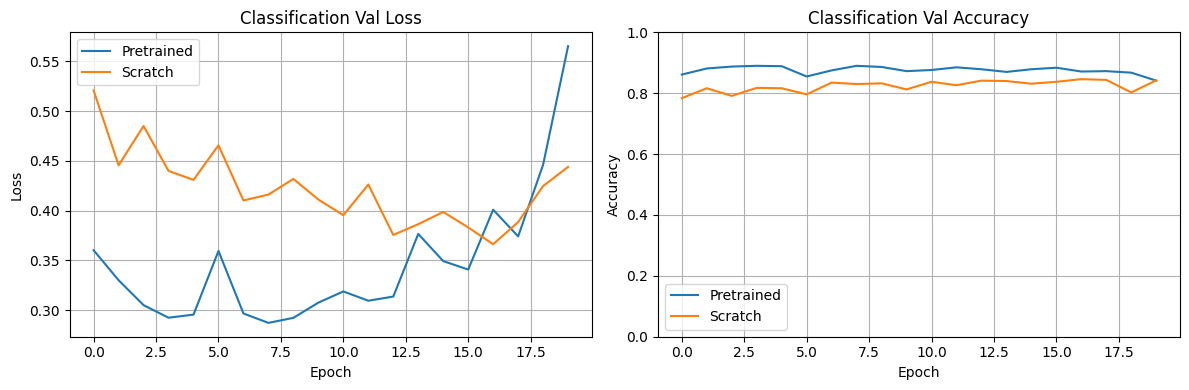


Pretrained Classification Test Metrics
Loss: 0.3495
Accuracy: 0.8555
TN=795, FP=220, FN=69, TP=916
ROC-AUC: 0.9241

Scratch Classification Test Metrics
Loss: 0.4118
Accuracy: 0.8180
TN=729, FP=286, FN=78, TP=907
ROC-AUC: 0.8874


/tmp/ipykernel_4098903/1158306755.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


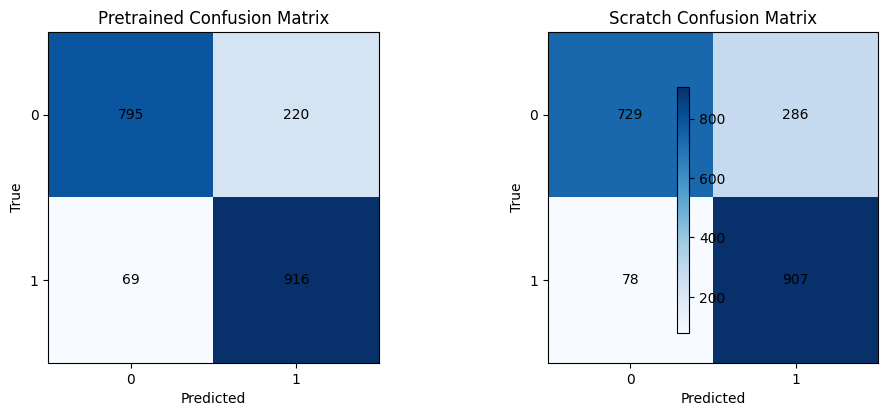

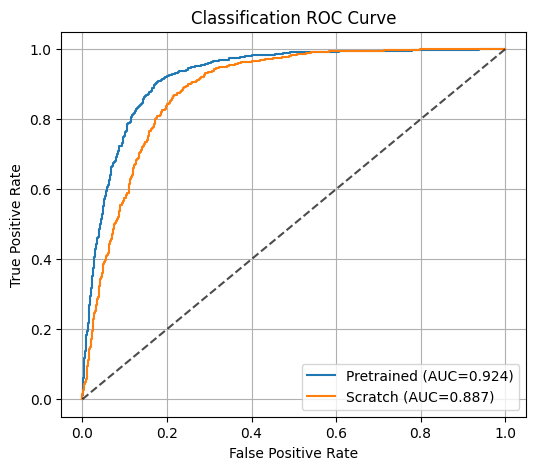

In [52]:
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
import numpy as np

# --------- Task 1: Classification ---------
print("Classification: Pretrained")
cls_pre_hist, cls_pre_test = train_and_eval("cls", pretrained=True, lr=1e-4, epochs=20, patience=20)

print("Classification: Scratch")
cls_scratch_hist, cls_scratch_test = train_and_eval("cls", pretrained=False, lr=1e-3, epochs=20, patience=20)

# Validation loss + accuracy comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(cls_pre_hist["val"], label="Pretrained")
axes[0].plot(cls_scratch_hist["val"], label="Scratch")
axes[0].set_title("Classification Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(cls_pre_hist["val_acc"], label="Pretrained")
axes[1].plot(cls_scratch_hist["val_acc"], label="Scratch")
axes[1].set_title("Classification Val Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.0, 1.0)
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

# Compute metrics + confusion matrix values
cls_results = {}
for name, out in [("Pretrained", cls_pre_test), ("Scratch", cls_scratch_test)]:
    tn, fp, fn, tp = confusion_matrix(out["labels"], out["preds"]).ravel()
    auc = roc_auc_score(out["labels"], out["probs"] )
    acc = (out["preds"] == out["labels"]).mean()
    cls_results[name] = {
        "cm": np.array([[tn, fp], [fn, tp]]),
        "auc": auc,
        "acc": acc,
        "loss": out["loss"],
        "labels": out["labels"],
        "probs": out["probs"]
    }

    print(f"\n{name} Classification Test Metrics")
    print(f"Loss: {out['loss']:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    print(f"ROC-AUC: {auc:.4f}")

# Confusion matrix plots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name in zip(axes, ["Pretrained", "Scratch"]):
    cm = cls_results[name]["cm"]
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.tight_layout()
plt.show()

# ROC curve
fpr_pre, tpr_pre, _ = roc_curve(cls_results["Pretrained"]["labels"], cls_results["Pretrained"]["probs"] )
fpr_scr, tpr_scr, _ = roc_curve(cls_results["Scratch"]["labels"], cls_results["Scratch"]["probs"] )

plt.figure(figsize=(6, 5))
plt.plot(fpr_pre, tpr_pre, label=f"Pretrained (AUC={cls_results['Pretrained']['auc']:.3f})")
plt.plot(fpr_scr, tpr_scr, label=f"Scratch (AUC={cls_results['Scratch']['auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.7)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Classification ROC Curve")
plt.grid(True)
plt.legend()
plt.show()

### Task 2: Mass Regression

Run pretrained vs scratch for `m` and compare validation/test MSE.

In [ ]:
# --------- Task 2: Mass Regression ---------
print("Mass: Pretrained")
mass_pre_hist, mass_pre_test = train_and_eval("mass", pretrained=True, lr=1e-4, epochs=12, patience=3)

print("Mass: Scratch")
mass_scratch_hist, mass_scratch_test = train_and_eval("mass", pretrained=False, lr=1e-4, epochs=12, patience=3)

plt.figure(figsize=(6, 4))
plt.plot(mass_pre_hist["val"], label="Pretrained")
plt.plot(mass_scratch_hist["val"], label="Scratch")
plt.title("Mass Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid(True)
plt.legend()
plt.show()

print("Mass Test MSE")
print(f"Pretrained: {mass_pre_test['loss']:.4f}")
print(f"Scratch:    {mass_scratch_test['loss']:.4f}")

### Task 3: pT Regression

Run pretrained vs scratch for `pT` and compare validation/test MSE.

In [ ]:
# --------- Task 3: pT Regression ---------
print("pT: Pretrained")
pt_pre_hist, pt_pre_test = train_and_eval("pt", pretrained=True, lr=1e-4, epochs=12, patience=3)

print("pT: Scratch")
pt_scratch_hist, pt_scratch_test = train_and_eval("pt", pretrained=False, lr=1e-4, epochs=12, patience=3)

plt.figure(figsize=(6, 4))
plt.plot(pt_pre_hist["val"], label="Pretrained")
plt.plot(pt_scratch_hist["val"], label="Scratch")
plt.title("pT Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid(True)
plt.legend()
plt.show()

print("pT Test MSE")
print(f"Pretrained: {pt_pre_test['loss']:.4f}")
print(f"Scratch:    {pt_scratch_test['loss']:.4f}")

### Ideas to Improve Classification Accuracy

1. **Tune threshold, not only 0.5**
   - Pick decision threshold on validation set (maximize F1, balanced accuracy, or physics-driven operating point).

2. **Class imbalance handling**
   - If labels are imbalanced, use `BCEWithLogitsLoss(pos_weight=...)` and/or weighted sampling in the train loader.

3. **Stronger augmentation for jet images**
   - Mild geometric/intensity augmentations that preserve physics can improve generalization.

4. **Learning-rate schedule**
   - Keep low LR for pretrained encoder, but use cosine decay + warmup and potentially a slightly higher LR for classification head.

5. **Freeze-then-unfreeze strategy**
   - First train only the head for a few epochs, then unfreeze the full encoder.

6. **Longer training with early stopping**
   - Increase max epochs and rely on validation-based early stopping to avoid overfitting.

7. **Cross-validation on the 80% development split**
   - 3–5 folds can provide a more robust estimate and better hyperparameter selection before final test evaluation.